# This project explores a public health dataset on diabetes outcomes. The objective is to analyze diabetes data, compare two groups, perform data cleaning, generate descriptive statistics, create a visualization, and provide a brief conclusion.

In [2]:
import pandas as pd

url = 'https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv'
df = pd.read_csv(url)

print(df.head())

   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
url = "https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv"
df = pd.read_csv(url)

df.head()


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
import numpy as np

# Replace "?" with NaN
df_clean = df.replace("?", np.nan)

# Convert age ranges like "[50-60)" → midpoint (55)
def midpoint(age_range):
    if pd.isna(age_range):
        return np.nan
    low = int(age_range[1: age_range.index("-")])
    high = int(age_range[age_range.index("-")+1 : age_range.index(")")])
    return (low + high) / 2

df_clean["age_num"] = df_clean["age"].apply(midpoint)

df_clean[["age", "age_num"]].head()


,age,age_num
0,[0-10),5.0
1,[10-20),15.0
2,[20-30),25.0
3,[30-40),35.0
4,[40-50),45.0


In [8]:
group_A = df_clean[df_clean["diabetesMed"] == "Yes"]      # Comparison - Group A: Patients with diabetes medication = "Yes" -- Group B: Patients with diabetes medication = "No"
group_B = df_clean[df_clean["diabetesMed"] == "No"]       # Length of hospital stay (time_in_hospital)


In [10]:
stats_A = group_A["time_in_hospital"].astype(float).describe()
stats_B = group_B["time_in_hospital"].astype(float).describe()

stats_A, stats_B


(count    78363.000000
 mean         4.497977
 std          3.004532
 min          1.000000
 25%          2.000000
 50%          4.000000
 75%          6.000000
 max         14.000000
 Name: time_in_hospital, dtype: float64,
 count    23403.000000
 mean         4.054480
 std          2.893131
 min          1.000000
 25%          2.000000
 50%          3.000000
 75%          5.000000
 max         14.000000
 Name: time_in_hospital, dtype: float64)

/tmp/ipykernel_19766/848130993.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


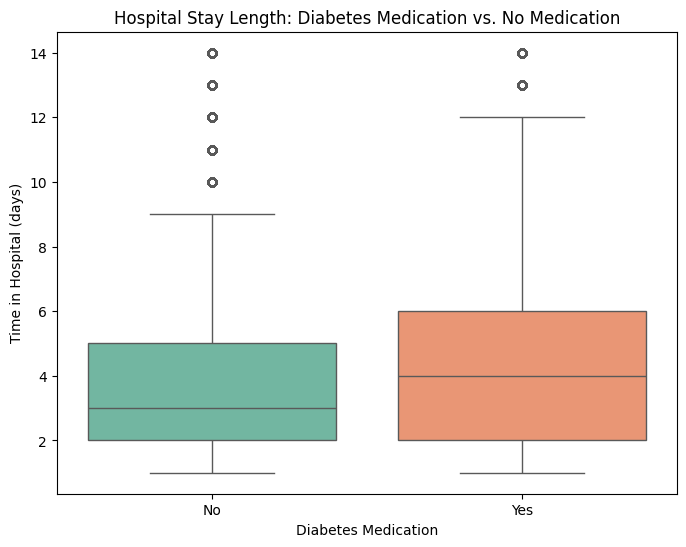

In [14]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df_clean,
    x="diabetesMed",
    y="time_in_hospital",
    palette="Set2"
)
plt.title("Hospital Stay Length: Diabetes Medication vs. No Medication")
plt.xlabel("Diabetes Medication")
plt.ylabel("Time in Hospital (days)")
plt.show()


In [ ]:
# Conculsion: Patients who were prescribed diabetes medication tended to have slightly longer hospital stays compared to those who were not. This may reflect greater illness severity or more complex care needs among medicated patients. Further analysis would be needed to determine whether medication status directly influences length of stay.
